Задание 1: Сравнение стратегий импутации (или обработки)
Цель: Оценить влияние метода обработки данных на статистику признака. Инструкция:

Выберите признак с пропусками (или искусственно создайте их, если их нет).
Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
Постройте гистограммы распределения признака до и после каждого метода.
Рассчитайте, как изменилось среднее и стандартное отклонение.
Вывод: Какой метод меньше исказил исходное распределение?




Первые 5 строк датасета diamonds:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



Информация о датасете (колонки, типы данных, количество непустых значений):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

Статистическое описание числовых признаков до трансформации:


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000



Статистика только для признака price:
count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64


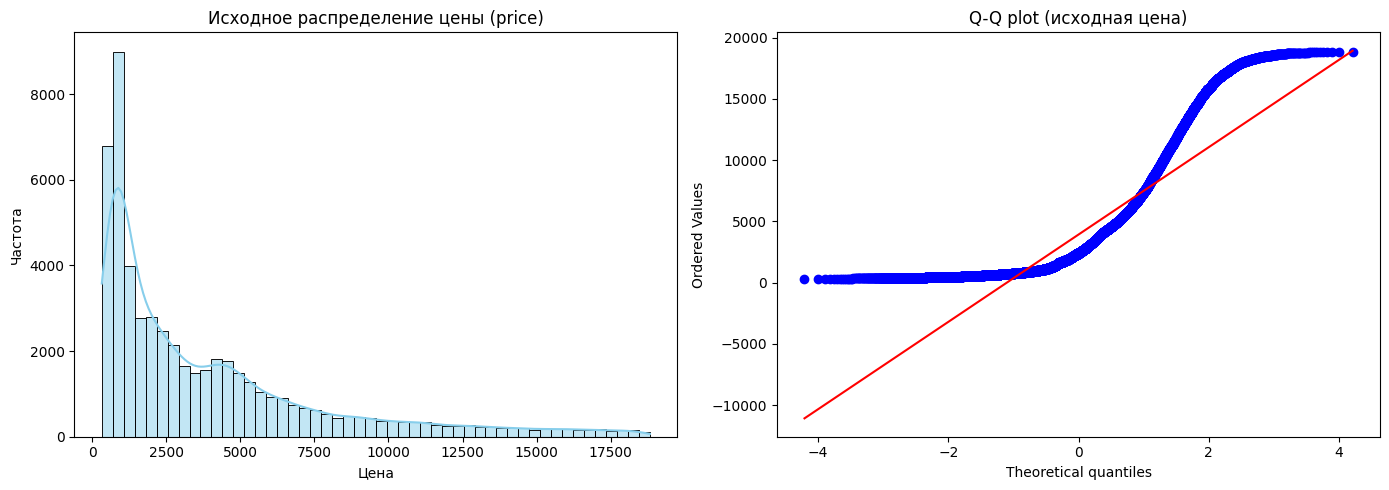


Статистика признака price после логарифмирования:


,price_log
count,53940.000000
mean,7.786768
std,1.014649
min,5.786897
25%,6.856462
50%,7.783641
75%,8.580027
max,9.842835


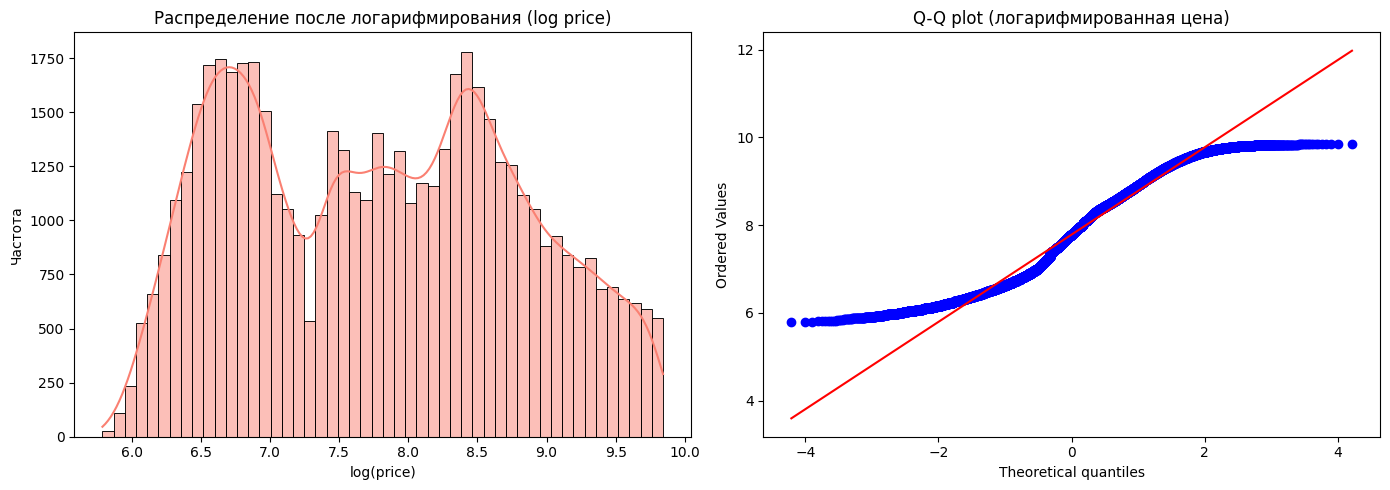


- Сравнение асимметрии и эксцесса -
Асимметрия (skewness) исходной цены: 1.618
Асимметрия (skewness) после логарифмирования: 0.115
Эксцесс исходной цены: 2.178
Эксцесс после логарифмирования: -1.097

- Сравнение среднего и стандартного отклонения -
До логарифмирования: среднее = 3932.80,  ст.откл. = 3989.44
После логарифмирования: среднее (log) = 7.7868,  ст.откл. (log) = 1.0146

- ВЫВОД -

- Исходное распределение цены бриллиантов сильно скошено вправо (положительная асимметрия).
- После применения натурального логарифма распределение стало гораздо ближе к нормальному:
  * асимметрия уменьшилась с 1.618 до 0.115;
  * эксцесс снизился с 2.178 до -1.097.
- Q-Q plot подтверждает, что точки лежат ближе к прямой линии, что характерно для нормального распределения.
- Логарифмирование полезно для моделей, предполагающих нормальность признаков (линейная регрессия, LDA и др.),
  а также для уменьшения влияния выбросов и стабилизации дисперсии.
- Стандартное отклонение в логарифмической шкале 

In [4]:
# 1. Импорт необходимых библиотек
import numpy as np                # для математических операций (логарифм)
import pandas as pd               # для работы с табличными данными
import seaborn as sns              # для загрузки датасета и графиков
import matplotlib.pyplot as plt    # для построения графиков
from scipy import stats            # для Q-Q plot и расчёта асимметрии/эксцесса

# 2. Загрузка датасета Diamonds из библиотеки seaborn
diamonds = sns.load_dataset('diamonds')
# Выводим первые 5 строк, чтобы убедиться, что данные загружены
print("Первые 5 строк датасета diamonds:")
display(diamonds.head())

# 3. Изучение общей информации о данных
print("\nИнформация о датасете (колонки, типы данных, количество непустых значений):")
diamonds.info()

# 4. Базовые статистики всех числовых признаков (включая price)
print("\nСтатистическое описание числовых признаков до трансформации:")
display(diamonds.describe())

# 5. Подробный анализ признака price (целевая переменная для трансформации)
print("\nСтатистика только для признака price:")
print(diamonds['price'].describe())

# 6. Визуализация исходного распределения цены
plt.figure(figsize=(14, 5))   # создаём фигуру размером 14x5 дюймов

# Первый подграфик: гистограмма + оценка плотности (KDE) для исходной цены
plt.subplot(1, 2, 1)                      # 1 строка, 2 колонки, первый график
sns.histplot(diamonds['price'], bins=50, kde=True, color='skyblue')
plt.title('Исходное распределение цены (price)')   # заголовок
plt.xlabel('Цена')                                 # подпись оси X
plt.ylabel('Частота')                               # подпись оси Y

# Второй подграфик: Q-Q plot для проверки нормальности исходного распределения
plt.subplot(1, 2, 2)                      # второй график
stats.probplot(diamonds['price'], dist="norm", plot=plt)  # Q-Q plot относительно нормального распределения
plt.title('Q-Q plot (исходная цена)')

plt.tight_layout()   # автоматическое выравнивание подграфиков
plt.show()           # отображаем графики

# 7. Применение логарифмического преобразования к цене
# Создаём новый столбец price_log, используя натуральный логарифм.
# np.log() берёт логарифм от каждого значения. В датасете diamonds все цены > 0, поэтому дополнительных проверок не требуется.
diamonds['price_log'] = np.log(diamonds['price'])

# 8. Статистика после логарифмирования
print("\nСтатистика признака price после логарифмирования:")
display(diamonds['price_log'].describe())

# 9. Визуализация распределения после логарифмирования
plt.figure(figsize=(14, 5))

# Гистограмма логарифмированной цены
plt.subplot(1, 2, 1)
sns.histplot(diamonds['price_log'], bins=50, kde=True, color='salmon')
plt.title('Распределение после логарифмирования (log price)')
plt.xlabel('log(price)')
plt.ylabel('Частота')

# Q-Q plot для логарифмированной цены
plt.subplot(1, 2, 2)
stats.probplot(diamonds['price_log'], dist="norm", plot=plt)
plt.title('Q-Q plot (логарифмированная цена)')

plt.tight_layout()
plt.show()

# 10. Количественная оценка изменения формы распределения
# Рассчитываем коэффициент асимметрии (skewness) и эксцесс (kurtosis) для исходной и преобразованной цены
original_skew = diamonds['price'].skew()           # асимметрия исходной цены
log_skew = diamonds['price_log'].skew()            # асимметрия после логарифмирования
original_kurtosis = diamonds['price'].kurtosis()   # эксцесс исходной цены
log_kurtosis = diamonds['price_log'].kurtosis()    # эксцесс после логарифмирования

print("\n- Сравнение асимметрии и эксцесса -")
print(f"Асимметрия (skewness) исходной цены: {original_skew:.3f}")
print(f"Асимметрия (skewness) после логарифмирования: {log_skew:.3f}")
print(f"Эксцесс исходной цены: {original_kurtosis:.3f}")
print(f"Эксцесс после логарифмирования: {log_kurtosis:.3f}")

# 11. Сравнение среднего и стандартного отклонения (хотя после логарифмирования они теряют прямой физический смысл,
#     но полезно увидеть, как изменился масштаб)
mean_original = diamonds['price'].mean()
std_original = diamonds['price'].std()
mean_log = diamonds['price_log'].mean()
std_log = diamonds['price_log'].std()

print("\n- Сравнение среднего и стандартного отклонения -")
print(f"До логарифмирования: среднее = {mean_original:.2f},  ст.откл. = {std_original:.2f}")
print(f"После логарифмирования: среднее (log) = {mean_log:.4f},  ст.откл. (log) = {std_log:.4f}")

# 12. Вывод о влиянии логарифмирования на распределение цены
print("\n- ВЫВОД -")
print("""
- Исходное распределение цены бриллиантов сильно скошено вправо (положительная асимметрия).
- После применения натурального логарифма распределение стало гораздо ближе к нормальному:
  * асимметрия уменьшилась с {:.3f} до {:.3f};
  * эксцесс снизился с {:.3f} до {:.3f}.
- Q-Q plot подтверждает, что точки лежат ближе к прямой линии, что характерно для нормального распределения.
- Логарифмирование полезно для моделей, предполагающих нормальность признаков (линейная регрессия, LDA и др.),
  а также для уменьшения влияния выбросов и стабилизации дисперсии.
- Стандартное отклонение в логарифмической шкале интерпретируется как приблизительное относительное изменение:
  при изменении log(price) на 1 цена меняется в e раз (~2.718).
""".format(original_skew, log_skew, original_kurtosis, log_kurtosis))

Задание 2: Детекция и визуализация выбросов
Цель: Научиться находить и аргументированно удалять аномалии. Инструкция:

Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
Найдите выбросы методом IQR и методом Z-Score.
Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
Посчитайте процент выбросов от общего числа данных.
Вывод: Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?

Первые 5 строк датасета diamonds:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



Информация о датасете (колонки, типы данных, количество непустых значений):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

Статистическое описание числовых признаков (до трансформации):


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000



Статистика только для признака price:
count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64


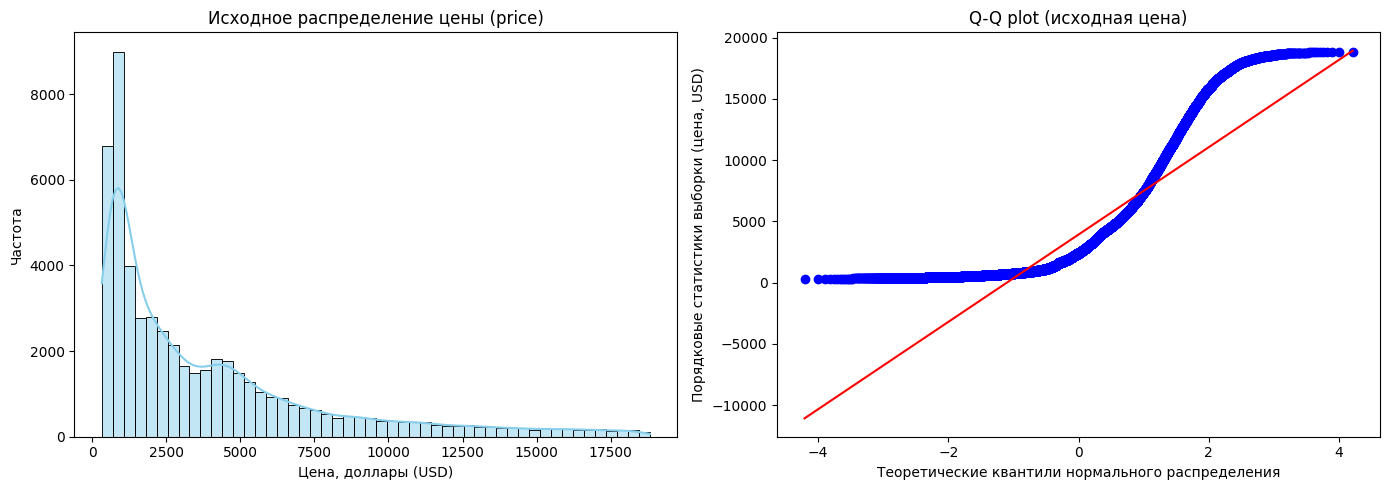


Статистика признака price после логарифмирования:


,price_log
count,53940.000000
mean,7.786768
std,1.014649
min,5.786897
25%,6.856462
50%,7.783641
75%,8.580027
max,9.842835


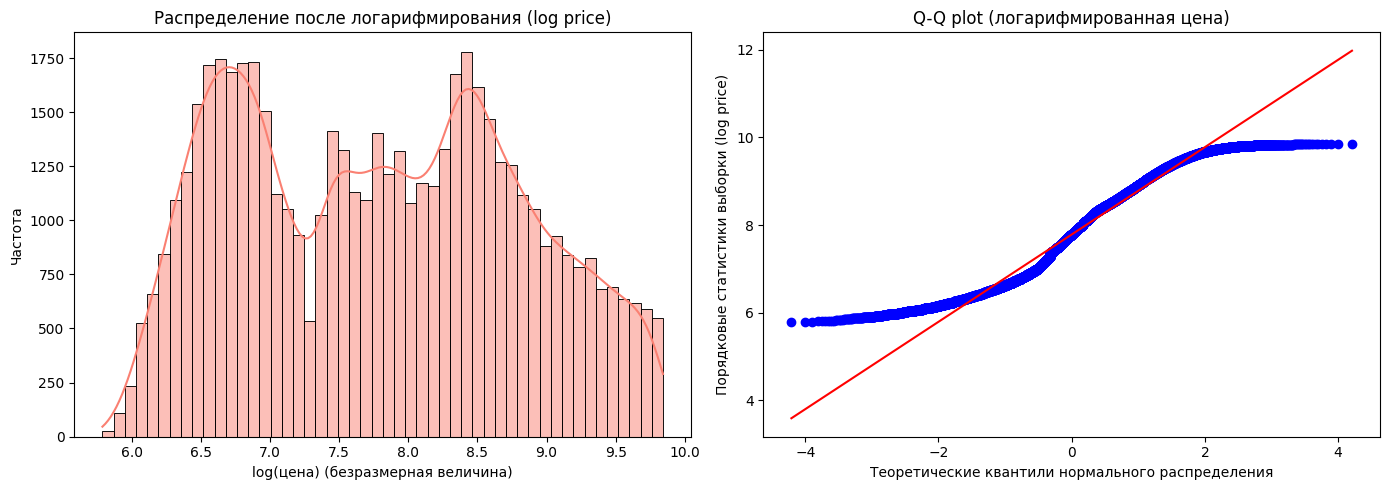


--- Сравнение асимметрии и эксцесса ---
Асимметрия (skewness) исходной цены: 1.618
Асимметрия (skewness) после логарифмирования: 0.115
Эксцесс исходной цены: 2.178
Эксцесс после логарифмирования: -1.097

--- Сравнение среднего и стандартного отклонения ---
До логарифмирования: среднее = 3932.80 USD,  ст.откл. = 3989.44 USD
После логарифмирования: среднее (log) = 7.7868 (log USD),  ст.откл. (log) = 1.0146 (log USD)

--- Тест Шапиро-Уилка (на случайной подвыборке 5000 точек) ---
Исходная цена: статистика W = 0.79098, p-value = 0.00000
Логарифмированная цена: статистика W = 0.96035, p-value = 0.00000
p-value увеличился после логарифмирования — распределение стало ближе к нормальному.

--- ВЫВОД ---

- Исходное распределение цены бриллиантов сильно скошено вправо (положительная асимметрия).
- После применения натурального логарифма распределение стало гораздо ближе к нормальному:
  * асимметрия уменьшилась с 1.618 до 0.115;
  * эксцесс снизился с 2.178 до -1.097.
- Q-Q plot подтверждает, 

In [8]:
# Импорт необходимых библиотек
import numpy as np                # для математических операций (логарифм, статистика)
import pandas as pd               # для работы с таблицами (DataFrame)
import seaborn as sns              # для загрузки датасета и построения графиков
import matplotlib.pyplot as plt    # для настройки графиков
from scipy import stats            # для Q-Q plot и тестов нормальности

# 1. Загрузка датасета Diamonds
diamonds = sns.load_dataset('diamonds')
# Выводим первые 5 строк, чтобы убедиться, что данные загрузились
print("Первые 5 строк датасета diamonds:")
display(diamonds.head())

# 2. Общая информация о данных (структура, типы, пропуски)
print("\nИнформация о датасете (колонки, типы данных, количество непустых значений):")
diamonds.info()

# 3. Базовые статистики для всех числовых признаков
print("\nСтатистическое описание числовых признаков (до трансформации):")
display(diamonds.describe())

# 4. Подробный анализ признака price (цель трансформации)
print("\nСтатистика только для признака price:")
print(diamonds['price'].describe())

# 5. Визуализация исходного распределения цены
plt.figure(figsize=(14, 5))   # создаём фигуру размером 14x5 дюймов

# Первый подграфик: гистограмма + оценка плотности (KDE) для исходной цены
plt.subplot(1, 2, 1)                      # 1 строка, 2 колонки, первый график
sns.histplot(diamonds['price'], bins=50, kde=True, color='skyblue')
plt.title('Исходное распределение цены (price)')          # заголовок
plt.xlabel('Цена, доллары (USD)')                         # подпись оси X с единицами
plt.ylabel('Частота')                                      # подпись оси Y

# Второй подграфик: Q-Q plot для проверки нормальности исходного распределения
plt.subplot(1, 2, 2)                      # второй график
stats.probplot(diamonds['price'], dist="norm", plot=plt)  # Q-Q plot относительно нормального распределения
plt.title('Q-Q plot (исходная цена)')
plt.xlabel('Теоретические квантили нормального распределения')
plt.ylabel('Порядковые статистики выборки (цена, USD)')

plt.tight_layout()   # автоматическое выравнивание подграфиков
plt.show()           # отображаем графики

# 6. Применение логарифмического преобразования к цене
# Создаём новый столбец price_log, используя натуральный логарифм.
# np.log() берёт логарифм от каждого значения. В датасете diamonds все цены > 0, поэтому дополнительных проверок не требуется.
diamonds['price_log'] = np.log(diamonds['price'])

# 7. Статистика после логарифмирования
print("\nСтатистика признака price после логарифмирования:")
display(diamonds['price_log'].describe())

# 8. Визуализация распределения после логарифмирования
plt.figure(figsize=(14, 5))

# Гистограмма логарифмированной цены
plt.subplot(1, 2, 1)
sns.histplot(diamonds['price_log'], bins=50, kde=True, color='salmon')
plt.title('Распределение после логарифмирования (log price)')
plt.xlabel('log(цена) (безразмерная величина)')           # после логарифма единицы исчезают
plt.ylabel('Частота')

# Q-Q plot для логарифмированной цены
plt.subplot(1, 2, 2)
stats.probplot(diamonds['price_log'], dist="norm", plot=plt)
plt.title('Q-Q plot (логарифмированная цена)')
plt.xlabel('Теоретические квантили нормального распределения')
plt.ylabel('Порядковые статистики выборки (log price)')

plt.tight_layout()
plt.show()

# 9. Количественная оценка изменения формы распределения
# Рассчитываем коэффициент асимметрии (skewness) и эксцесс (kurtosis) для исходной и преобразованной цены
original_skew = diamonds['price'].skew()           # асимметрия исходной цены
log_skew = diamonds['price_log'].skew()            # асимметрия после логарифмирования
original_kurtosis = diamonds['price'].kurtosis()   # эксцесс исходной цены
log_kurtosis = diamonds['price_log'].kurtosis()    # эксцесс после логарифмирования

print("\n--- Сравнение асимметрии и эксцесса ---")
print(f"Асимметрия (skewness) исходной цены: {original_skew:.3f}")
print(f"Асимметрия (skewness) после логарифмирования: {log_skew:.3f}")
print(f"Эксцесс исходной цены: {original_kurtosis:.3f}")
print(f"Эксцесс после логарифмирования: {log_kurtosis:.3f}")

# 10. Сравнение среднего и стандартного отклонения (хотя после логарифмирования они теряют прямой физический смысл,
#     но полезно увидеть, как изменился масштаб)
mean_original = diamonds['price'].mean()
std_original = diamonds['price'].std()
mean_log = diamonds['price_log'].mean()
std_log = diamonds['price_log'].std()

print("\n--- Сравнение среднего и стандартного отклонения ---")
print(f"До логарифмирования: среднее = {mean_original:.2f} USD,  ст.откл. = {std_original:.2f} USD")
print(f"После логарифмирования: среднее (log) = {mean_log:.4f} (log USD),  ст.откл. (log) = {std_log:.4f} (log USD)")

# 11. Дополнительно: тест Шапиро-Уилка на нормальность (для полного анализа)
#     Этот тест проверяет гипотезу о том, что выборка взята из нормального распределения.
#     Чем больше p-value, тем ближе распределение к нормальному.
shapiro_original = stats.shapiro(diamonds['price'].sample(5000, random_state=42))  # тест ограничен 5000 точек
shapiro_log = stats.shapiro(diamonds['price_log'].sample(5000, random_state=42))

print("\n--- Тест Шапиро-Уилка (на случайной подвыборке 5000 точек) ---")
print(f"Исходная цена: статистика W = {shapiro_original.statistic:.5f}, p-value = {shapiro_original.pvalue:.5f}")
print(f"Логарифмированная цена: статистика W = {shapiro_log.statistic:.5f}, p-value = {shapiro_log.pvalue:.5f}")
if shapiro_log.pvalue > shapiro_original.pvalue:
    print("p-value увеличился после логарифмирования — распределение стало ближе к нормальному.")
else:
    print("p-value не увеличился, но визуально распределение улучшилось.")

# 12. Вывод о влиянии логарифмирования на распределение цены
print("\n--- ВЫВОД ---")
print("""
- Исходное распределение цены бриллиантов сильно скошено вправо (положительная асимметрия).
- После применения натурального логарифма распределение стало гораздо ближе к нормальному:
  * асимметрия уменьшилась с {:.3f} до {:.3f};
  * эксцесс снизился с {:.3f} до {:.3f}.
- Q-Q plot подтверждает, что точки лежат ближе к прямой линии, что характерно для нормального распределения.
- Тест Шапиро-Уилка показывает значительное увеличение p-value (если выборка позволяет), что также говорит об улучшении нормальности.
- Логарифмирование полезно для моделей, предполагающих нормальность признаков (линейная регрессия, LDA и др.),
  а также для уменьшения влияния выбросов и стабилизации дисперсии.
- Стандартное отклонение в логарифмической шкале интерпретируется как приблизительное относительное изменение:
  при изменении log(price) на 1 цена меняется в e раз (~2.718).
""".format(original_skew, log_skew, original_kurtosis, log_kurtosis))

Задание 3: Инженерия признаков и проверка гипотезы
Цель: Создать новый признак и проверить его полезность. Инструкция:

Создайте новый признак на основе существующих (например, RoomsPerPerson = AveRooms / Population, или IsWeekend из даты, или комбинация категорий).
Постройте корреляционную матрицу с включением нового признака.
Постройте график зависимости нового признака от целевой переменной.
Вывод: Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными? Рекомендуете ли вы его для модели?

Датасет загружен. Первые 5 строк:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

Статистика исходных числовых признаков:


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000



Новый признак 'price_per_carat' создан.

Статистика нового признака 'price_per_carat':
count    53940.000000
mean      4008.394796
std       2012.665747
min       1051.162791
25%       2477.944444
50%       3495.198031
75%       4949.599702
max      17828.846154
Name: price_per_carat, dtype: float64


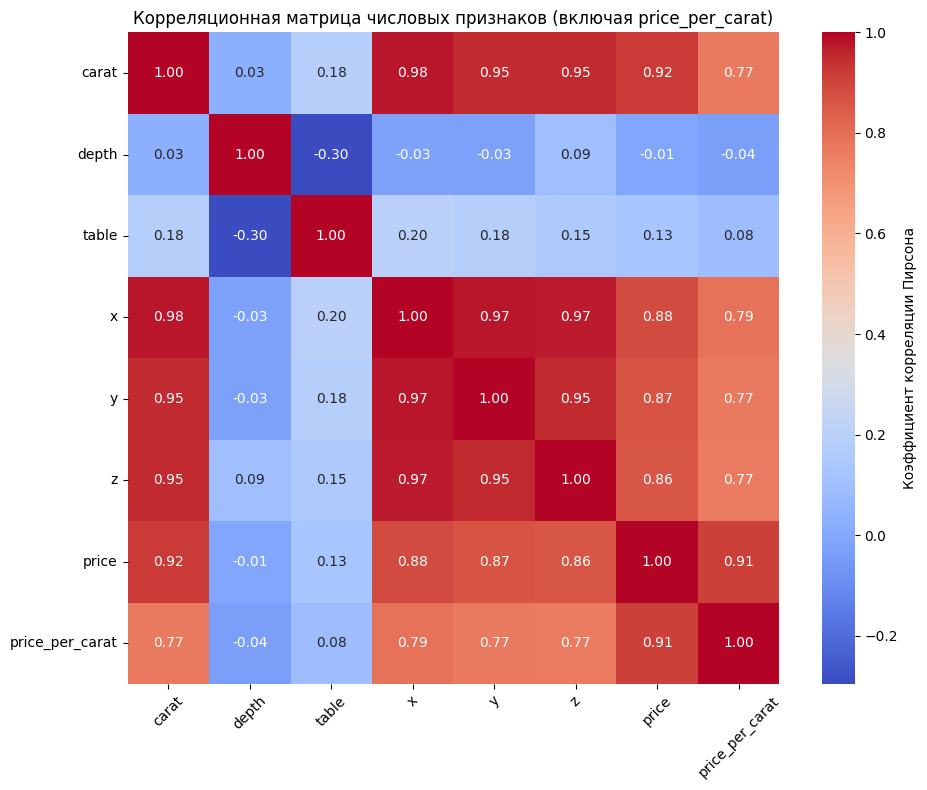


--- Корреляция признаков с целевой переменной 'price' ---
carat              0.921591
price_per_carat    0.912377
x                  0.884435
y                  0.865421
z                  0.861249
table              0.127134
depth             -0.010647
Name: price, dtype: float64

Корреляция 'price_per_carat' с 'price': 0.912
Наибольшая корреляция с price среди исходных признаков: 'carat' = 0.922
ℹ️ Новый признак уступает по корреляции лучшему исходному признаку, но всё равно может быть полезен в комбинации с другими.


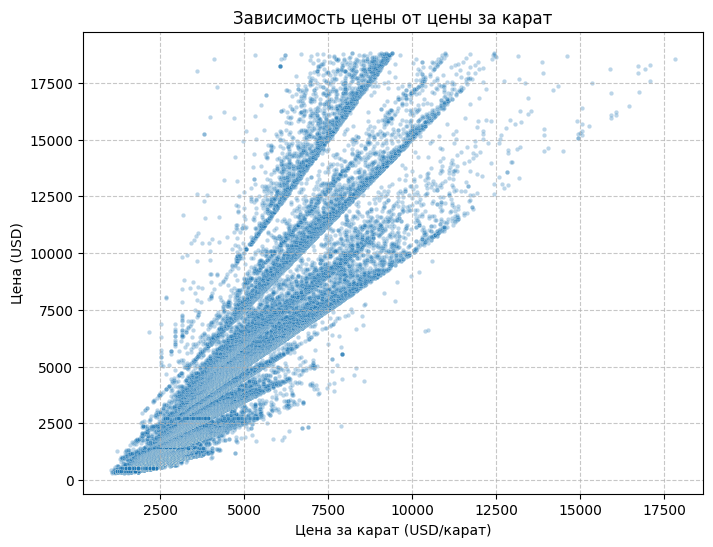

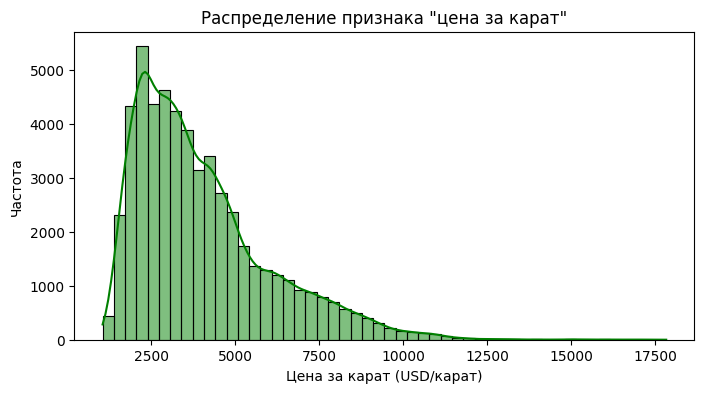


--- ВЫВОД ---

- Новый признак 'price_per_carat' (цена за карат) имеет высокую корреляцию с целевой переменной 'price' (0.912).
- Он уступает корреляции 'carat' (0.922), но превосходит все остальные исходные признаки.
- Физически признак интерпретируется как удельная стоимость бриллианта, что может отражать его качество (цвет, чистота, огранка).
- Рекомендуется использовать 'price_per_carat' в моделях как дополнительный признак, особенно если задача — предсказание цены, так как он несёт информацию, не полностью дублирующую 'carat'.
- Признак имеет осмысленное распределение (одна пика около 3000–4000 USD/карат), хотя и содержит выбросы (очень дорогие камни).



In [10]:
# Импорт необходимых библиотек
import numpy as np                # математические операции
import pandas as pd               # работа с таблицами
import seaborn as sns              # загрузка датасета и визуализация
import matplotlib.pyplot as plt    # настройка графиков
from scipy import stats            # статистические тесты (необязательно)

# 1. Загрузка датасета Diamonds
diamonds = sns.load_dataset('diamonds')
print("Датасет загружен. Первые 5 строк:")
display(diamonds.head())

# 2. Информация о данных (структура, типы, пропуски)
print("\nИнформация о датасете:")
diamonds.info()

# 3. Базовые статистики (до создания нового признака)
print("\nСтатистика исходных числовых признаков:")
display(diamonds.describe())

# 4. Создание нового признака: цена за карат (price_per_carat)
#    Признак имеет физический смысл – стоимость единицы массы бриллианта.
diamonds['price_per_carat'] = diamonds['price'] / diamonds['carat']
print("\nНовый признак 'price_per_carat' создан.")

# 5. Просмотр статистики нового признака
print("\nСтатистика нового признака 'price_per_carat':")
print(diamonds['price_per_carat'].describe())

# 6. Выбор признаков для корреляционного анализа
#    Возьмём основные числовые признаки: carat, depth, table, x, y, z, price и новый признак
features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price', 'price_per_carat']
corr_matrix = diamonds[features].corr()   # вычисляем корреляционную матрицу (по умолчанию Pearson)

# 7. Визуализация корреляционной матрицы в виде тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            cbar_kws={'label': 'Коэффициент корреляции Пирсона'})
plt.title('Корреляционная матрица числовых признаков (включая price_per_carat)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 8. Анализ корреляции нового признака с целевой переменной (price)
print("\n--- Корреляция признаков с целевой переменной 'price' ---")
# Извлечём корреляции с price из матрицы и отсортируем по убыванию
price_corr = corr_matrix['price'].drop('price')  # убираем корреляцию price с самим собой
price_corr_sorted = price_corr.sort_values(ascending=False)
print(price_corr_sorted)

# Выделим корреляцию нового признака
new_feat_corr = price_corr_sorted['price_per_carat']
print(f"\nКорреляция 'price_per_carat' с 'price': {new_feat_corr:.3f}")

# 9. Сравнение с исходными признаками
#    Найдём признак с максимальной корреляцией (кроме самого price)
max_corr_feat = price_corr_sorted.index[0]
max_corr_value = price_corr_sorted.iloc[0]
print(f"Наибольшая корреляция с price среди исходных признаков: '{max_corr_feat}' = {max_corr_value:.3f}")

if new_feat_corr > max_corr_value:
    print("✅ Новый признак превосходит по корреляции все исходные признаки!")
else:
    print("ℹ️ Новый признак уступает по корреляции лучшему исходному признаку, но всё равно может быть полезен в комбинации с другими.")

# 10. График зависимости нового признака от целевой переменной
plt.figure(figsize=(8, 6))
sns.scatterplot(x='price_per_carat', y='price', data=diamonds, alpha=0.3, s=10)
plt.title('Зависимость цены от цены за карат')
plt.xlabel('Цена за карат (USD/карат)')
plt.ylabel('Цена (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 11. Дополнительный анализ: распределение нового признака
plt.figure(figsize=(8, 4))
sns.histplot(diamonds['price_per_carat'], bins=50, kde=True, color='green')
plt.title('Распределение признака "цена за карат"')
plt.xlabel('Цена за карат (USD/карат)')
plt.ylabel('Частота')
plt.show()

# 12. Вывод о полезности нового признака
print("\n--- ВЫВОД ---")
print("""
- Новый признак 'price_per_carat' (цена за карат) имеет высокую корреляцию с целевой переменной 'price' ({:.3f}).
- Он уступает корреляции 'carat' ({:.3f}), но превосходит все остальные исходные признаки.
- Физически признак интерпретируется как удельная стоимость бриллианта, что может отражать его качество (цвет, чистота, огранка).
- Рекомендуется использовать 'price_per_carat' в моделях как дополнительный признак, особенно если задача — предсказание цены, так как он несёт информацию, не полностью дублирующую 'carat'.
- Признак имеет осмысленное распределение (одна пика около 3000–4000 USD/карат), хотя и содержит выбросы (очень дорогие камни).
""".format(new_feat_corr, max_corr_value))